## Computer Vision
#### A deeplearning category which works with all thing related to digital images 

#### Necessary libraries

In [2]:
## Import PyTroch
import torch
import torch.nn as nn

## Import TorchVision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

# Import Pillow
from PIL import Image

# Import Matplotlib
import matplotlib.pyplot as plt

print("PyTorch", torch.__version__)
print("TorchVision", torchvision.__version__)

PyTorch 2.10.0
TorchVision 0.25.0


In [3]:
fashion_dataset_train = datasets.FashionMNIST(
    root='data',
    train=True,
    transform=ToTensor(),
    target_transform=None,
    download=True
)
fashion_dataset_train

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
class_names = fashion_dataset_train.classes

In [5]:
fashion_dataset_test = datasets.FashionMNIST(
    root='data',
    train=False,
    transform=ToTensor(),
    target_transform=None,
    download=True
)
fashion_dataset_test

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [6]:
BATCH_SIZE=32
EPOCHS=5

device = 'cpu'
if torch.mps.is_available(): device = 'mps'
device

'mps'

In [183]:
train_dataloader = DataLoader(
    fashion_dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_dataloader = DataLoader(
    fashion_dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)
"Train "+ str(len(train_dataloader)) +", Test: "+ str(len(test_dataloader)) + " batches of 32"

'Train 1875, Test: 313 batches of 32'

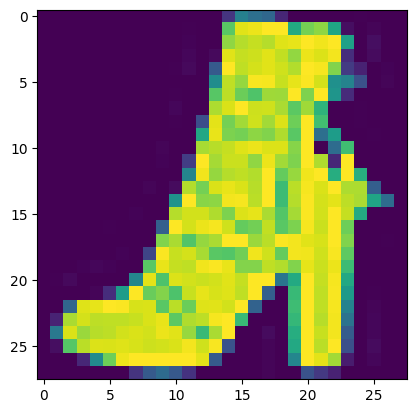

In [8]:
train_features, train_labels = next(iter(train_dataloader))
plt.imshow(train_features[11][0])

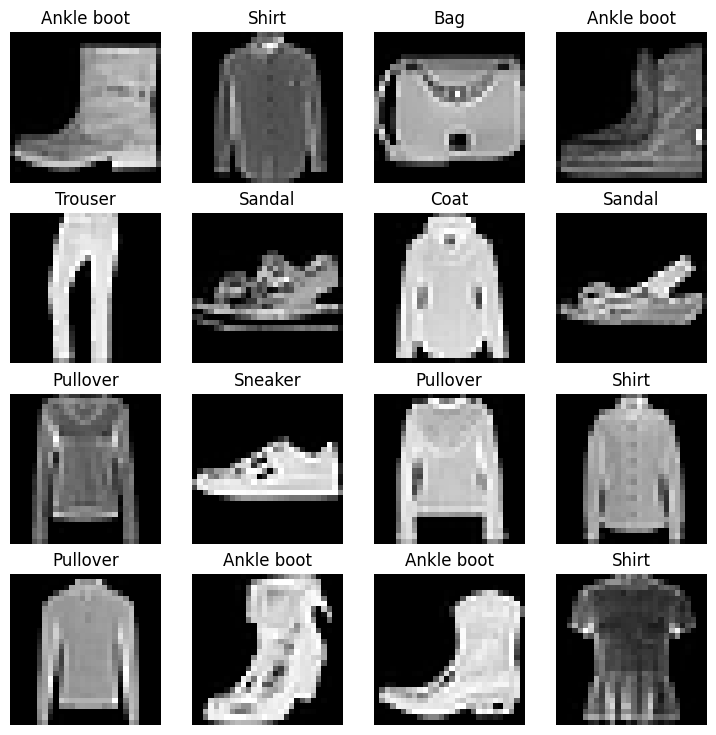

In [9]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(fashion_dataset_train), size=[1]).item()
    img, label = fashion_dataset_train[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

In [10]:
class FashionClassifierV0(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, out_features),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)

FashionClassifierV0

__main__.FashionClassifierV0

In [11]:
model0 = FashionClassifierV0(
    in_features=784,
    hidden_features=100,
    out_features=10
)

In [12]:
len(class_names) ## as it is output features

10

In [13]:
optimizer = torch.optim.SGD(model0.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

In [96]:
def train_step(
    model: nn.Module,
    optimizer:any,
    loss_func: nn.Module,
    dataloader: DataLoader,
    acc_func,
    device: str,
): 
    """Returns dictionary of loss and accuracy of the model"""
    loss_all, acc_all = 0.0, 0.0
    model.to(device)
    model.train()
    
    for X, y in tqdm(dataloader):

        X = X.to(device)
        y = y.to(device).long() 

        y_logits = model(X)   
        
        loss = loss_func(y_logits, y) 
        acc = acc_func(y, y_logits.argmax(dim=1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_all += loss.item()
        acc_all += acc.item() if torch.is_tensor(acc) else acc

    return {
        "loss": loss_all / len(dataloader),
        "accuracy": acc_all / len(dataloader)
    }
    
def eval_step(
    model: nn.Module,
    loss_func: nn.Module,
    dataloader: DataLoader,
    acc_func,
    device: str,
): 
    loss_all, acc_all = 0.0, 0.0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device).long() 
    
            y_logits = model(X)   
            
            loss = loss_func(y_logits, y) 
            acc = acc_func(y, y_logits.argmax(dim=1))
            
            loss_all += loss.item()
            acc_all += acc.item() if torch.is_tensor(acc) else acc

    return {
        "loss": loss_all / len(dataloader),
        "accuracy": acc_all / len(dataloader),
        "model_name": model.__class__.__name__
    }


In [97]:
from helper_functions import accuracy_fn
from tqdm.auto import tqdm

In [98]:
for epoch in range(EPOCHS):
    train_result = train_step(
        model=model0,
        optimizer=optimizer,
        loss_func=loss_fn,
        dataloader=train_dataloader,
        acc_func=accuracy_fn,
        device=device,
    )
    
    print(f"Epoch: {epoch} | Avg Train Loss: {train_result['loss']} | Avg Train Accuracy: {train_result['accuracy']}")
    

  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 0 | Avg Train Loss: 0.3376376218477885 | Avg Train Accuracy: 87.93666666666667


  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 1 | Avg Train Loss: 0.3376376218477885 | Avg Train Accuracy: 87.93666666666667


  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 2 | Avg Train Loss: 0.3376376218477885 | Avg Train Accuracy: 87.93666666666667


  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 3 | Avg Train Loss: 0.3376376218477885 | Avg Train Accuracy: 87.93666666666667


  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 4 | Avg Train Loss: 0.3376376218477885 | Avg Train Accuracy: 87.93666666666667


In [99]:
test_result = eval_step(
        model=model0,
        loss_func=loss_fn,
        dataloader=test_dataloader,
        acc_func=accuracy_fn,
        device=device,
)
test_result

{'loss': 0.38805225910470126,
 'accuracy': 86.08226837060703,
 'model_name': 'FashionClassifierV0'}

In [100]:
conv2 = nn.Conv2d(
    in_channels=1,
    out_channels=4,
    stride=2,
    padding=1,
    kernel_size=3
)
conv2

Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

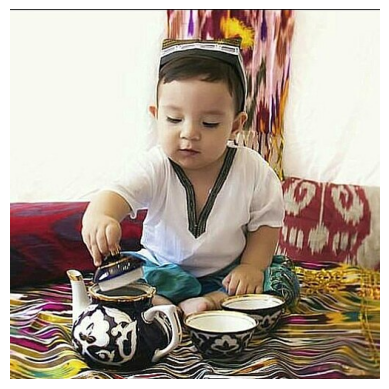

In [101]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

person_image = Image.open("image.png")

transform = transforms.ToTensor()
person_image_data = transform(person_image)
plt.imshow(person_image_data.permute(1, 2, 0))
plt.axis("off")


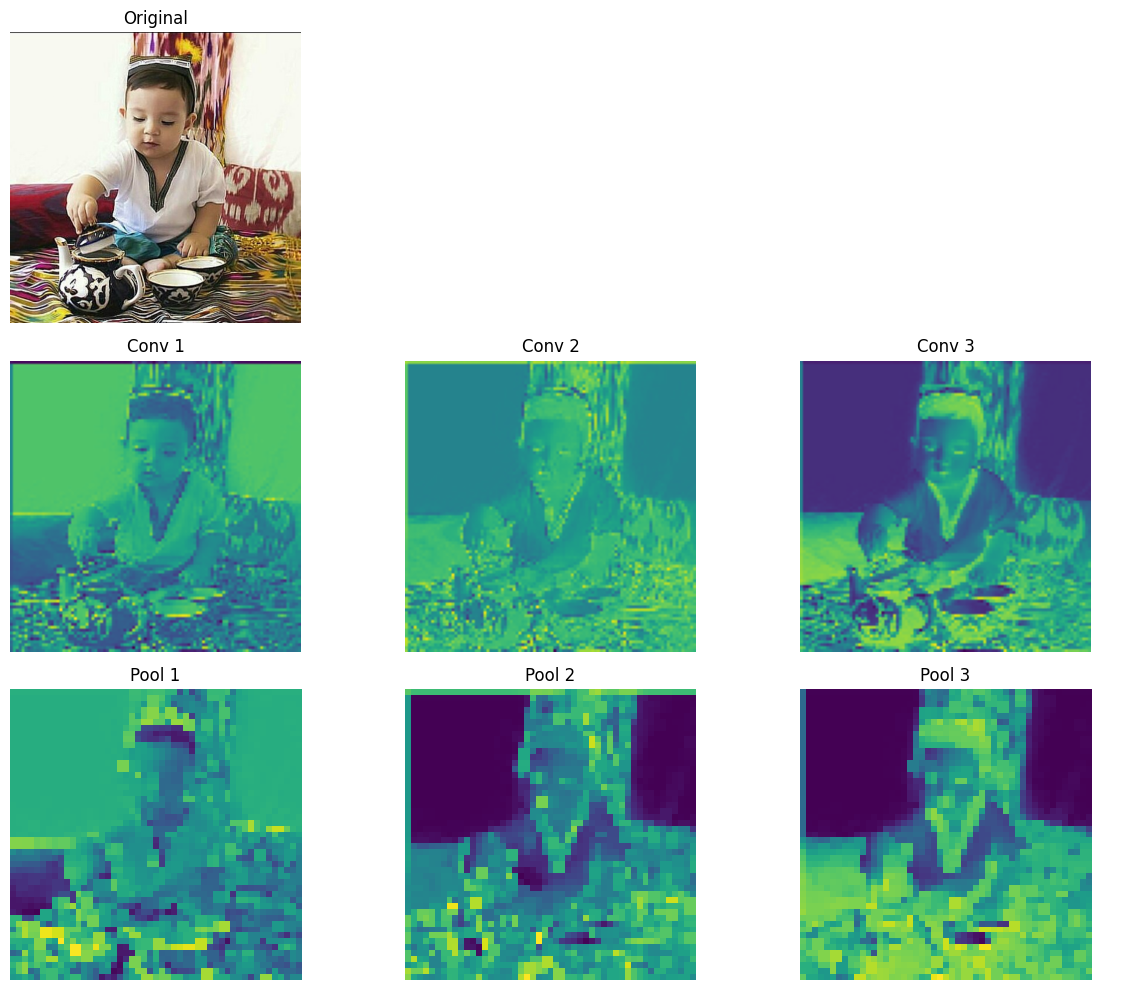

In [102]:
import torch.nn as nn
import matplotlib.pyplot as plt

conv = nn.Conv2d(3, 3, kernel_size=5, padding=1, stride=5)
pool = nn.MaxPool2d(kernel_size=3, stride=2)

conv_out = conv(person_image_data)          # (1, 3, H, W)
pool_out = pool(conv_out)       # (1, 3, H/2, W/2)

conv_np = conv_out.squeeze(0).detach().numpy()
pool_np = pool_out.squeeze(0).detach().numpy()

C = conv_np.shape[0]

fig, axs = plt.subplots(3, C, figsize=(4*C, 10))

# ---- Row 0: original (large) ----
axs[0, 0].imshow(person_image_data.permute(1, 2, 0), cmap="gray")
axs[0, 0].set_title("Original")
axs[0, 0].axis("off")

# hide unused cells in row 0
for j in range(1, C):
    axs[0, j].axis("off")

# ---- Row 1: conv outputs ----
for i in range(C):
    axs[1, i].imshow(conv_np[i])
    axs[1, i].set_title(f"Conv {i+1}")
    axs[1, i].axis("off")

# ---- Row 2: pooled outputs ----
for i in range(C):
    axs[2, i].imshow(pool_np[i])
    axs[2, i].set_title(f"Pool {i+1}")
    axs[2, i].axis("off")

plt.tight_layout()
plt.show()


In [174]:
class FashionClassifierV2(nn.Module):
    def __init__(self, in_channels, hidden_units, out_channels):
        super().__init__()
        
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2)
        )

        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(490, out_channels),
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_layer_1(x)
        # print(f"Conv stack 1 shape: {x.shape}")
        x = self.conv_layer_2(x)
        # print(f"Conv stack 2 shape: {x.shape}")
        x = self.classifier(x)
        # print(f"Classifier stack shape: {x.shape}")
        return x



In [175]:
model2 = FashionClassifierV2(
    in_channels=1,
    hidden_units=20,
    out_channels=len(class_names)
)
model2

FashionClassifierV2(
  (conv_layer_1): Sequential(
    (0): Conv2d(1, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_layer_2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

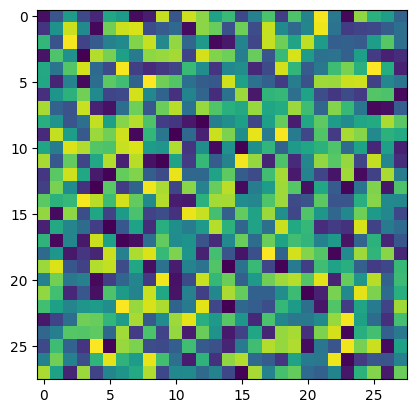

In [176]:
image_rand = torch.rand(1, 28, 28)
plt.imshow(image_rand.squeeze())

In [177]:
model2(image_rand.unsqueeze(dim=0))

tensor([[-0.0202,  0.0385, -0.0521,  0.0137, -0.0174, -0.0555,  0.0089, -0.0167,
         -0.0411, -0.0064]], grad_fn=<AddmmBackward0>)

In [178]:
optimizer = torch.optim.SGD(model2.parameters(), lr=0.09)

In [179]:
for epoch in range(3):
    train_result = train_step(
        model=model2,
        optimizer=optimizer,
        loss_func=loss_fn,
        dataloader=train_dataloader,
        acc_func=accuracy_fn,
        device=device,
    )
    
    print(f"Epoch: {epoch} | Avg Train Loss: {train_result['loss']} | Avg Train Accuracy: {train_result['accuracy']}")

  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 0 | Avg Train Loss: 0.5687687580823898 | Avg Train Accuracy: 79.39


  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 1 | Avg Train Loss: 0.34727783139745394 | Avg Train Accuracy: 87.32166666666667


  0%|          | 0/1875 [00:00<?, ?it/s]

Epoch: 2 | Avg Train Loss: 0.30333200302322705 | Avg Train Accuracy: 88.99166666666666


In [184]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [185]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !uv pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.24.0


10000


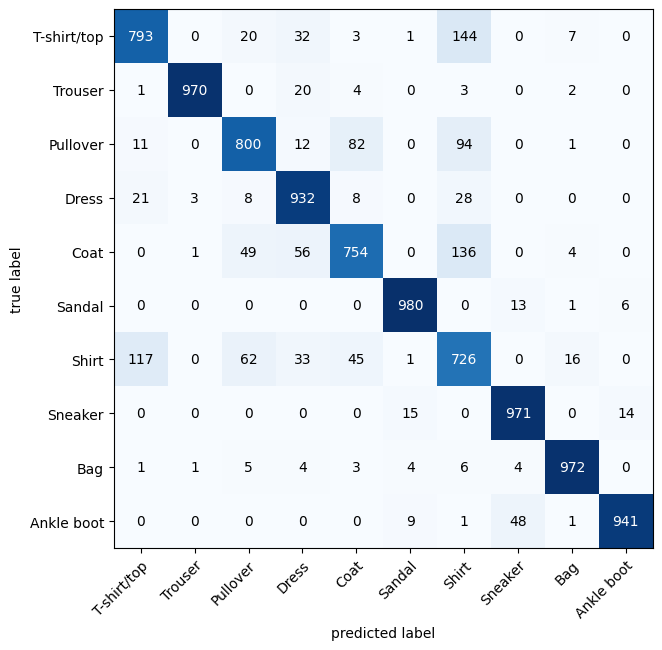

In [186]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=fashion_dataset_test.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy 
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
)


print(confmat_tensor.numpy().sum())